In [1]:
from helpers.load import *
from helpers.select_scenario import select_scenario
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
scenario_folder = select_scenario()

Select a scenario:
[0]: lake
[1]: soil
Selected scenario: soil

Select a test run:
[0]: 2025-03-01_07:32
Selected run: 2025-03-01_07:32


In [3]:
def calculate_node_positions(node_pos_df: pd.DataFrame, time: float) -> dict:
    # Get the latest position before the given time for each node
    positions = node_pos_df[node_pos_df['Time'] <= time].groupby('NodeId').last()
    return {
        row.name: np.array([row['X'], row['Y'], row['Z']]) 
        for _, row in positions.iterrows()
    }

def calculate_distance(pos1: np.ndarray, pos2: np.ndarray) -> float:
    return np.sqrt(np.sum((pos1 - pos2) ** 2))

In [4]:
node_pos_df = load_node_pos_df(scenario_folder)
tx_df = load_phy_tx_begin(scenario_folder)
rx_df = load_phy_rx_end(scenario_folder)

In [5]:
bin_size: float = 0.01

# Create results storage
distance_bins = {}

# Process each transmission
for _, tx in tx_df.iterrows():
    # Get positions at transmission time
    positions = calculate_node_positions(node_pos_df, tx['Time'])
    
    if tx['SourceNodeId'] in positions and tx['DestinationNodeId'] in positions:
        distance = calculate_distance(
            positions[tx['SourceNodeId']], 
            positions[tx['DestinationNodeId']]
        )
        
        # Bin the distance
        bin_index = int(distance / bin_size) * bin_size
        
        if bin_index not in distance_bins:
            distance_bins[bin_index] = {
                'packets': 0,
                'bytes': 0,
                'drops': 0,
                'retries': 0,
                'time_range': tx['Time']
            }
        
        # Count retries
        if tx['IsRetry'] == 'true':
            distance_bins[bin_index]['retries'] += 1
        
        # Find corresponding reception or drop
        rx_match = rx_df[
            (rx_df['PacketId'] == tx['PacketId']) &
            (rx_df['SourceNodeId'] == tx['SourceNodeId']) &
            (rx_df['DestinationNodeId'] == tx['DestinationNodeId'])
        ]
        
        if not rx_match.empty:
            distance_bins[bin_index]['packets'] += 1
            distance_bins[bin_index]['bytes'] += tx['PacketSize']
            distance_bins[bin_index]['time_range'] = max(
                distance_bins[bin_index]['time_range'],
                tx['Time']
            )
                
# Prepare plotting data
distances = []
throughputs = []
sent_packets = []
received_packets = []

for dist, data in sorted(distance_bins.items()):
    distances.append(dist + bin_size/2)  # Use bin center
    
    # Calculate throughput in bytes per second
    if data['time_range'] > 0:
        throughput = (data['bytes'] * 8) / (data['time_range'] * 1e-9)
    else:
        throughput = 0
    throughputs.append(throughput)
    
    # Get packet statistics
    sent_packets.append(data['packets'] + data['drops'])  # Total attempts
    received_packets.append(data['packets'])

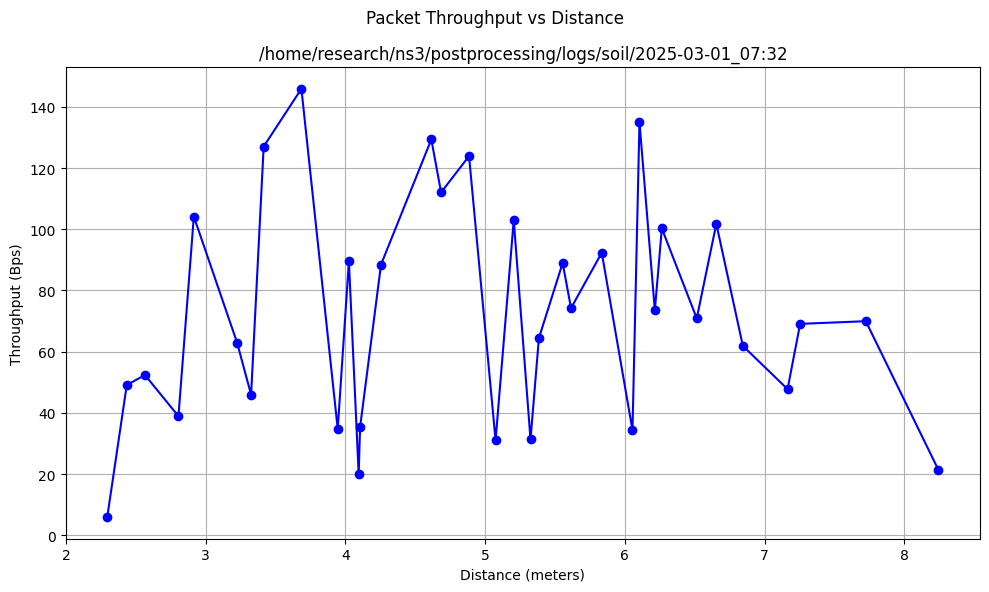

In [6]:
# Plot throughput
plt.figure(figsize=(10, 6))
plt.plot(distances, throughputs, 'bo-')
plt.grid(True)
plt.xlabel('Distance (meters)')
plt.ylabel('Throughput (Bps)')
plt.suptitle('Packet Throughput vs Distance')
plt.title(scenario_folder)

plt.tight_layout()